In [1]:
import cleanup
import plotting
import stat_analysis
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
import tkinter
from tkinter import filedialog
import scipy as scp
import scipy.stats as scpst
import framewise_stats
import figure_prep
pd.options.mode.use_inf_as_na = True

d:\Experiment Work\larva-locater Repo\larva-locater\Structured\cleanup.py:13: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True
C:\Users\hpnhp\AppData\Local\Temp\ipykernel_13668\385418557.py:20: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [3]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df = cleanup.data_to_dataframe(filepath)

In [4]:
primary_df = primary_df[primary_df['Frame']<600]
primary_df = cleanup.calculate_distance_from_fixed_point(primary_df)
primary_df = cleanup.categorize_values(primary_df, 'X', 14, 1.5)

primary_df_interp = cleanup.interpolate_missing_values(primary_df)
primary_df_interp = cleanup.calculate_distance_from_fixed_point(primary_df_interp)

In [18]:
df_csd = primary_df_interp[(primary_df_interp['Genotype'] == 'CSDxTNTe') | 
                           (primary_df_interp['Genotype'] == 'CSDxTNTi')]

df_trh = primary_df_interp[(primary_df_interp['Genotype'] == 'TrhxTNTe') | 
                           (primary_df_interp['Genotype'] == 'TrhxTNTi')]

<string>:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



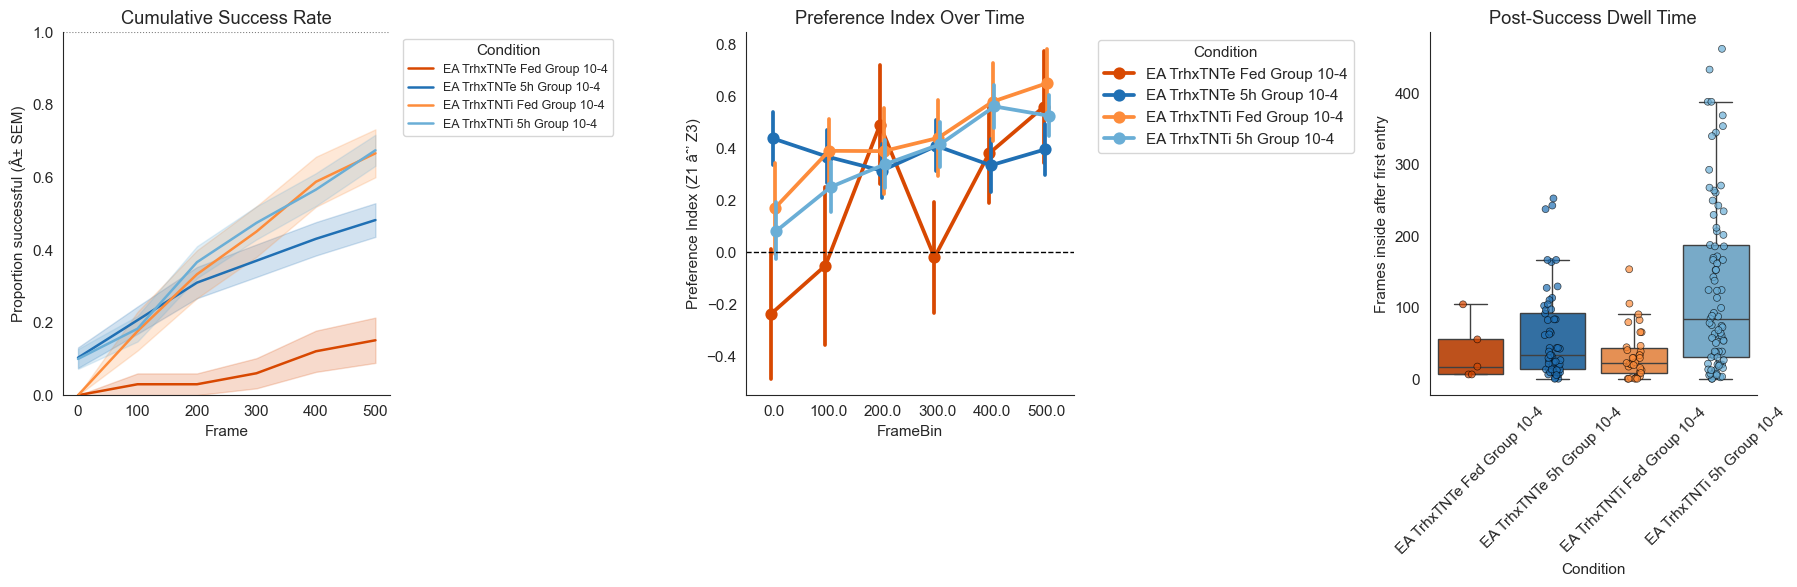

In [19]:
_,_,_ = figure_prep.plot_behavior_summary_overtime(df_trh)

In [13]:
primary_df_interp.Condition.unique()

array(['EA CSDxTNTe 5h Group 10-4', 'EA CSDxTNTe Fed Group 10-4', 'TRex',
       'EA CSDxTNTi 5h Group 10-4', 'EA CSDxTNTi Fed Group 10-4',
       'EA TrhxTNTe 5h Group 10-4', 'EA TrhxTNTe Fed Group 10-4',
       'EA TrhxTNTi 5h Group 10-4', 'EA TrhxTNTi Fed Group 10-4'],
      dtype=object)

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\figure_prep.py:2481: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  order=[display_labels[c] for c in ordered_conditions] if display_labels else ordered_conditions,
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\figure_prep.py:2516: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  order=[display_labels[c] for c in ordered_conditions] if display_labels else ordered_conditions,
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\figure_prep.py:2525: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

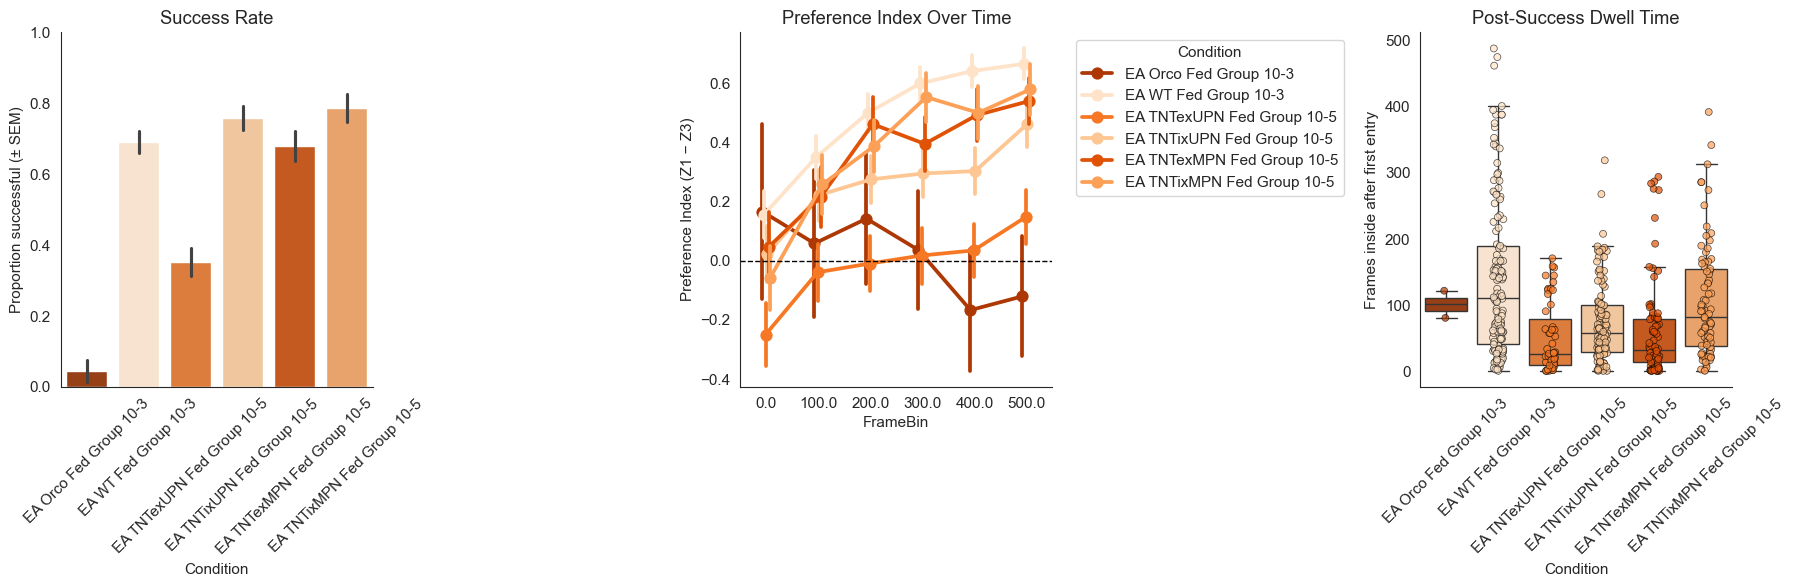

(                  Condition                     Individual  Success  \
 0    EA Orco Fed Group 10-3              Trial 1_fish0.csv        0   
 1    EA Orco Fed Group 10-3              Trial 1_fish1.csv        0   
 2    EA Orco Fed Group 10-3             Trial 1_fish10.csv        0   
 3    EA Orco Fed Group 10-3             Trial 1_fish11.csv        0   
 4    EA Orco Fed Group 10-3             Trial 1_fish12.csv        0   
 ..                      ...                            ...      ...   
 772    EA WT Fed Group 10-3  Trial8converted.avi_fish5.csv        1   
 773    EA WT Fed Group 10-3  Trial8converted.avi_fish6.csv        1   
 774    EA WT Fed Group 10-3  Trial8converted.avi_fish7.csv        0   
 775    EA WT Fed Group 10-3  Trial8converted.avi_fish8.csv        1   
 776    EA WT Fed Group 10-3  Trial8converted.avi_fish9.csv        0   
 
                   PlotLabel  
 0    EA Orco Fed Group 10-3  
 1    EA Orco Fed Group 10-3  
 2    EA Orco Fed Group 10-3  
 3    EA O

In [18]:
condition_order = ['EA Orco Fed Group 10-3', 'EA WT Fed Group 10-3', 
                   'EA TNTexUPN Fed Group 10-5', 'EA TNTixUPN Fed Group 10-5', 
                   'EA TNTexMPN Fed Group 10-5', 'EA TNTixMPN Fed Group 10-5']

figure_prep.plot_behavior_summary(primary_df_interp, condition_order=condition_order)

In [ ]:
df_trh_kir = primary_df_interp[(primary_df_interp['Genotype'] == 'TrhxKir')
                           |(primary_df_interp['Genotype'] == 'WTxKir')
                           |(primary_df_interp['Genotype'] == 'WTxTrh')
                           ]

df_csd_kir = primary_df_interp[(primary_df_interp['Genotype'] == 'CSDxKir')
                           |(primary_df_interp['Genotype'] == 'WTxKir')
                           |(primary_df_interp['Genotype'] == 'WTxCSD')
                           ]

In [ ]:
figure_prep.plot_behavior_summary(df_csd_kir)

In [22]:
primary_df_interp_10_4 = primary_df_interp[primary_df_interp['Concentration'] == '10-4']
primary_df_interp_10_4 = primary_df_interp_10_4[primary_df_interp_10_4['Collective'] == 'Group']
primary_df_interp_WT_10_4 = primary_df_interp_10_4[primary_df_interp_10_4['Genotype'] == 'WT']
primary_df_interp_Trh_10_4 = primary_df_interp_10_4[primary_df_interp_10_4['Genotype'] == 'Trh']

In [23]:
primary_df_interp_10_3 = primary_df_interp[primary_df_interp['Concentration'] == '10-3']
primary_df_interp_10_3 = primary_df_interp_10_3[primary_df_interp_10_3['Collective'] == 'Group']
primary_df_interp_WT_10_3 = primary_df_interp_10_3[primary_df_interp_10_3['Genotype'] == 'WT']
primary_df_interp_Trh_10_3 = primary_df_interp_10_3[primary_df_interp_10_3['Genotype'] == 'Trh']

In [24]:
primary_df_interp_10_5 = primary_df_interp[primary_df_interp['Concentration'] == '10-5']
primary_df_interp_10_5 = primary_df_interp_10_5[primary_df_interp_10_5['Collective'] == 'Group']
primary_df_interp_WT_10_5 = primary_df_interp_10_5[primary_df_interp_10_5['Genotype'] == 'WT']
primary_df_interp_Trh_10_5 = primary_df_interp_10_5[primary_df_interp_10_5['Genotype'] == 'Trh']

In [25]:
primary_df_interp_water = primary_df_interp[primary_df_interp['Condition'] == 'WA WT Fed Group 10-0']
primary_df_interp_WT_10_4_w = pd.concat([primary_df_interp_WT_10_4, primary_df_interp_water])

df_orco = primary_df_interp[primary_df_interp['Condition'] == 'EA Orco Fed Group 10-3']
primary_df_interp_WT_10_4_w = pd.concat([primary_df_interp_WT_10_4_w, df_orco])

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\figure_prep.py:2481: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  order=[display_labels[c] for c in ordered_conditions] if display_labels else ordered_conditions,
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\figure_prep.py:2516: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  order=[display_labels[c] for c in ordered_conditions] if display_labels else ordered_conditions,
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\figure_prep.py:2525: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

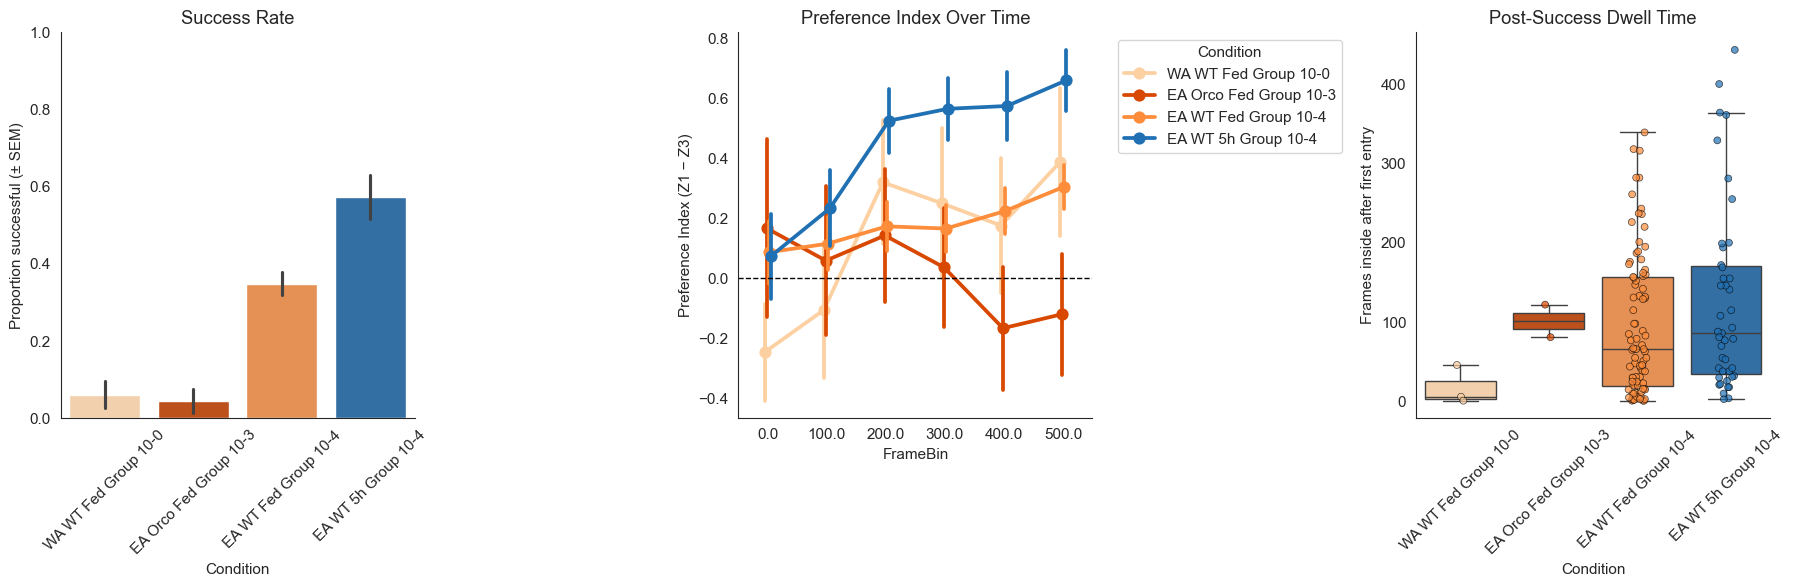

(                  Condition              Individual  Success  \
 0    EA Orco Fed Group 10-3       Trial 1_fish0.csv        0   
 1    EA Orco Fed Group 10-3       Trial 1_fish1.csv        0   
 2    EA Orco Fed Group 10-3      Trial 1_fish10.csv        0   
 3    EA Orco Fed Group 10-3      Trial 1_fish11.csv        0   
 4    EA Orco Fed Group 10-3      Trial 1_fish12.csv        0   
 ..                      ...                     ...      ...   
 419    WA WT Fed Group 10-0  Trial 6_conv_fish5.csv        0   
 420    WA WT Fed Group 10-0  Trial 6_conv_fish6.csv        0   
 421    WA WT Fed Group 10-0  Trial 6_conv_fish7.csv        0   
 422    WA WT Fed Group 10-0  Trial 6_conv_fish8.csv        0   
 423    WA WT Fed Group 10-0  Trial 6_conv_fish9.csv        0   
 
                   PlotLabel  
 0    EA Orco Fed Group 10-3  
 1    EA Orco Fed Group 10-3  
 2    EA Orco Fed Group 10-3  
 3    EA Orco Fed Group 10-3  
 4    EA Orco Fed Group 10-3  
 ..                      ...  
 

In [26]:
figure_prep.plot_behavior_summary(primary_df_interp_WT_10_4_w)

In [27]:
df_water_concs = primary_df_interp[primary_df_interp['Genotype'] == 'WT']
df_water_concs = df_water_concs[df_water_concs['Starvation'] == 'Fed']
df_water_concs = df_water_concs[df_water_concs['Collective'] == 'Group']
df_water_concs = pd.concat([primary_df_interp_water, df_water_concs])

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\figure_prep.py:2481: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  order=[display_labels[c] for c in ordered_conditions] if display_labels else ordered_conditions,
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\figure_prep.py:2516: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  order=[display_labels[c] for c in ordered_conditions] if display_labels else ordered_conditions,
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\figure_prep.py:2525: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

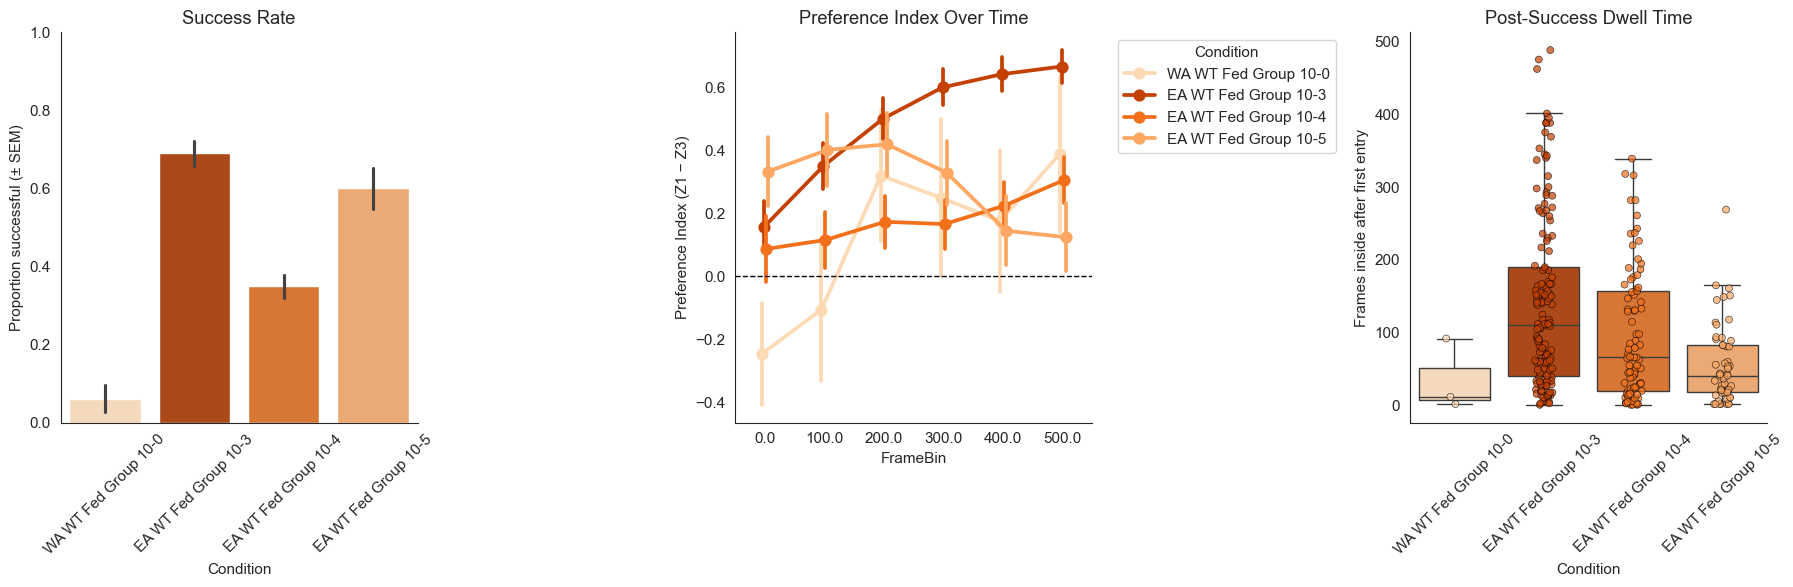

(                Condition                      Individual  Success  \
 0    EA WT Fed Group 10-3   Trial1Converted.avi_fish0.csv        0   
 1    EA WT Fed Group 10-3   Trial1Converted.avi_fish1.csv        0   
 2    EA WT Fed Group 10-3  Trial1Converted.avi_fish10.csv        1   
 3    EA WT Fed Group 10-3  Trial1Converted.avi_fish11.csv        0   
 4    EA WT Fed Group 10-3  Trial1Converted.avi_fish12.csv        0   
 ..                    ...                             ...      ...   
 599  WA WT Fed Group 10-0          Trial 6_conv_fish5.csv        0   
 600  WA WT Fed Group 10-0          Trial 6_conv_fish6.csv        0   
 601  WA WT Fed Group 10-0          Trial 6_conv_fish7.csv        0   
 602  WA WT Fed Group 10-0          Trial 6_conv_fish8.csv        0   
 603  WA WT Fed Group 10-0          Trial 6_conv_fish9.csv        0   
 
                 PlotLabel  
 0    EA WT Fed Group 10-3  
 1    EA WT Fed Group 10-3  
 2    EA WT Fed Group 10-3  
 3    EA WT Fed Group 10-3  
 

In [28]:
figure_prep.plot_behavior_summary(df_water_concs)

In [ ]:
figure_prep.plot_prefindex_and_successrate_combined(primary_df_interp_WT_10_4_w, radius=5)

In [ ]:
figure_prep.plot_probability_and_bootstrap_logistic(primary_df_interp_10_3, save_csv=False)

In [ ]:
print(primary_df_interp_WT_10_4["Starvation"].unique())
print(primary_df_interp_WT_10_4["Starvation"].value_counts())

In [ ]:
df_group = primary_df_interp[primary_df_interp['Collective'] == 'Group']

In [ ]:
pair_labels = {
    ('10-3', 'WT', 'Group'): "WT Group 10-3",
    ("10-4", "WT", "Group"): "WT Group 10-4",
    ("10-4", "WT", "Single"): "WT Single 10-4",
    ('10-5', 'WT', 'Group'): "WT Group 10-5",
    ('10-3', 'Trh', 'Group'): "Trh Group 10-3",
    ("10-4", "Trh", "Group"): "Trh Group 10-4",
    ("10-4", "Trh", "Single"): "Trh Single 10-4",
    ('10-5', 'Trh', 'Group'): "Trh Group 10-5"
}


figure_prep.plot_preferenceindex_hierarchical_matplotlib(df_group, frame_range=(400,600), pair_labels=None)

In [ ]:
primary_df_interp['Genotype'].unique()

In [ ]:
# df_WT_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WT') |
#                               (primary_df_interp['Genotype'] == 'Trh')]
# df_WT_Trh_EA = df_WT_Trh[df_WT_Trh['Odour'] == 'EA']
# df_WT_Trh_PA = df_WT_Trh[df_WT_Trh['Odour'] == 'PA']
# df_WT_Trh_1P = df_WT_Trh[df_WT_Trh['Odour'] == '1P']

# df_Kir_CSD_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKir') 
#                                  | (primary_df_interp['Genotype'] == 'TrhxKir')
#                                  | (primary_df_interp['Genotype'] == 'CSDxKir')
#                                  | (primary_df_interp['Genotype'] == 'WTxCSD')
#                                  | (primary_df_interp['Genotype'] == 'WTxTrh')]
# df_Kir_CSD_Trh = df_Kir_CSD_Trh[(df_Kir_CSD_Trh['Starvation'] == 'Fed')
#                               | (df_Kir_CSD_Trh['Starvation'] == '5h')]
# df_Kir_CSD_Trh_EA = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == 'EA']
# df_Kir_CSD_Trh_PA = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == 'PA']
# df_Kir_CSD_Trh_1P = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == '1P']

# df_Kir_CSD = df_Kir_CSD_Trh[(df_Kir_CSD_Trh['Genotype'] == 'WTxCSD')
#                         | (df_Kir_CSD_Trh['Genotype'] == 'WTxKir')
#                         | (df_Kir_CSD_Trh['Genotype'] == 'CSDxKir')]
# df_Kir_CSD_EA = df_Kir_CSD[df_Kir_CSD['Odour'] == 'EA']

# df_TNT_uPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexUPN')
#                             |  (primary_df_interp['Genotype'] == 'TNTixUPN')]

# df_TNT_MPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexMPN')
#                             |  (primary_df_interp['Genotype'] == 'TNTixMPN')]

# df_TNT_5HT1A = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT1A')
#                             |    (primary_df_interp['Genotype'] == 'TNTix5HT1A')]

# df_TNT_5HT7 = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT7')
#                             |   (primary_df_interp['Genotype'] == 'TNTix5HT7')]

In [ ]:
# WT and Trh dataframes for PA and 1P 
df_WT_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WT') 
                            | (primary_df_interp['Genotype'] == 'TRH')]


df_WT_Trh_PA = df_WT_Trh[df_WT_Trh['Odour'] == 'PA']
df_WT_Trh_1P = df_WT_Trh[df_WT_Trh['Odour'] == '1-P']


df_WT_PA = df_WT_Trh_PA[(df_WT_Trh_PA['Genotype'] == 'WT')]
df_Trh_PA = df_WT_Trh_PA[(df_WT_Trh_PA['Genotype'] == 'TRH')]

df_WT_PA_104 = df_WT_PA[df_WT_PA['Concentration'] == '10-4']
df_Trh_PA_104 = df_Trh_PA[df_Trh_PA['Concentration'] == '10-4']
df_PA_104 = pd.concat([df_WT_PA_104, df_Trh_PA_104])



df_WT_1P = df_WT_Trh_1P[(df_WT_Trh_1P['Genotype'] == 'WT')]
df_Trh_1P = df_WT_Trh_1P[(df_WT_Trh_1P['Genotype'] == 'TRH')]   

df_WT_1P_102 = df_WT_1P[df_WT_1P['Concentration'] == '10-2']
df_Trh_1P_102 = df_Trh_1P[df_Trh_1P['Concentration'] == '10-2']
df_1P_102 = pd.concat([df_WT_1P_102, df_Trh_1P_102])


#Kir crosses for PA and 1P 

df_KirCross = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKIR')
                                | (primary_df_interp['Genotype'] == 'TRHxKIR')
                                | (primary_df_interp['Genotype'] == 'CSDxKIR')
                                | (primary_df_interp['Genotype'] == 'WTxCSD')
                                | (primary_df_interp['Genotype'] == 'WTxTRH')]

df_KirCross_PA = df_KirCross[df_KirCross['Odour'] == 'PA']
df_KirCross_1P = df_KirCross[df_KirCross['Odour'] == '1-P']


df_KirCross_PA_CSD = df_KirCross_PA[(df_KirCross_PA['Genotype'] == 'WTxCSD')
                                    | (df_KirCross_PA['Genotype'] == 'CSDxKIR')
                                    | (df_KirCross_PA['Genotype'] == 'WTxKIR')]

df_KirCross_PA_TRH = df_KirCross_PA[(df_KirCross_PA['Genotype'] == 'WTxTRH')
                                    | (df_KirCross_PA['Genotype'] == 'TRHxKIR')
                                    | (df_KirCross_PA['Genotype'] == 'WTxKIR')]


df_KirCross_1P_CSD = df_KirCross_1P[(df_KirCross_1P['Genotype'] == 'WTxCSD')
                                    | (df_KirCross_1P['Genotype'] == 'CSDxKIR')
                                    | (df_KirCross_1P['Genotype'] == 'WTxKIR')]     

df_KirCross_1P_TRH = df_KirCross_1P[(df_KirCross_1P['Genotype'] == 'WTxTRH')
                                    | (df_KirCross_1P['Genotype'] == 'TRHxKIR')
                                    | (df_KirCross_1P['Genotype'] == 'WTxKIR')]



#Concentration validation --> EA

df_KirCross_EA = df_KirCross[df_KirCross['Odour'] == 'EA']

df_KirCross_EA_fed_5h = df_KirCross_EA[(df_KirCross_EA['Starvation'] == 'Fed')
                                      | (df_KirCross_EA['Starvation'] == '5h')]

df_WTxKir_EA_fed_5h = df_KirCross_EA_fed_5h[df_KirCross_EA_fed_5h['Genotype'] == 'WTxKIR']

df_WTxKir_EA_fed_5h_104_105 = df_WTxKir_EA_fed_5h[(df_WTxKir_EA_fed_5h['Concentration'] == '10-4')
                                                    | (df_WTxKir_EA_fed_5h['Concentration'] == '10-5')]



#starvation effects on WT and WTxKir crosses --> EA

df_EA = primary_df_interp[(primary_df_interp['Odour'] == 'EA')]
df_EA_105 = df_EA[(df_EA['Concentration'] == '10-5')]


df_EA_105_starvation = df_EA_105[(df_EA_105['Genotype'] == 'WT')
                             | (df_EA_105['Genotype'] == 'WTxKIR')]


# HT Kir crosses for EA

df_KirCross_HT = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKIR')
                                | (primary_df_interp['Genotype'] == 'WTx5HT7')
                                | (primary_df_interp['Genotype'] == 'WTx5HT1A') 
                                | (primary_df_interp['Genotype'] == '5HT7xKIR')
                                | (primary_df_interp['Genotype'] == '5HT1AxKIR')]

df_KirCross_HT_EA = df_KirCross_HT[df_KirCross_HT['Odour'] == 'EA']
df_KirCross_HT_EA_105 = df_KirCross_HT_EA[(df_KirCross_HT_EA['Concentration'] == '10-5')
                                          &((df_KirCross_HT_EA['Starvation'] == 'Fed')
                                            | (df_KirCross_HT_EA['Starvation'] == '5h'))]

df_KirCross_5HT7_EA_105 = df_KirCross_HT_EA_105[(df_KirCross_HT_EA_105['Genotype'] == 'WTx5HT7')
                                                | (df_KirCross_HT_EA_105['Genotype'] == '5HT7xKIR')
                                                | (df_KirCross_HT_EA_105['Genotype'] == 'WTxKIR')]
df_KirCross_5HT1A_EA_105 = df_KirCross_HT_EA_105[(df_KirCross_HT_EA_105['Genotype'] == 'WTx5HT1A')
                                                | (df_KirCross_HT_EA_105['Genotype'] == '5HT1AxKIR')
                                                | (df_KirCross_HT_EA_105['Genotype'] == 'WTxKIR')]

# uPN

df_TNTxuPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexUPN')
                            | (primary_df_interp['Genotype'] == 'TNTixUPN')
                            | (primary_df_interp['Genotype'] == 'TNTexuPN')
                            | (primary_df_interp['Genotype'] == 'TNTixuPN')]

df_TNTxuPN_EA_105 = df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA')
                               & (df_TNTxuPN['Concentration'] == '10-5')]

df_TNTxuPN_EA_103 = df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA')
                               & (df_TNTxuPN['Concentration'] == '10-3')]

#mPN

df_TNTxMPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexMPN')
                            | (primary_df_interp['Genotype'] == 'TNTixMPN')]

df_TNTxMPN_EA_105 = df_TNTxMPN[(df_TNTxMPN['Odour'] == 'EA')
                               & (df_TNTxMPN['Concentration'] == '10-5')]

# TNTx5HT7

df_TNTx5HT7 = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT7')
                            | (primary_df_interp['Genotype'] == 'TNTix5HT7')]

df_TNTx5HT7_EA_105 = df_TNTx5HT7[(df_TNTx5HT7['Odour'] == 'EA')
                               & (df_TNTx5HT7['Concentration'] == '10-5')]

df_TNTx5HT7_EA_103 = df_TNTx5HT7[(df_TNTx5HT7['Odour'] == 'EA')
                               & (df_TNTx5HT7['Concentration'] == '10-3')]


# TNTx5HT1A
df_TNTx5HT1A = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT1A')
                            | (primary_df_interp['Genotype'] == 'TNTix5HT1A')]

df_TNTx5HT1A_EA_105 = df_TNTx5HT1A[(df_TNTx5HT1A['Odour'] == 'EA')
                               & (df_TNTx5HT1A['Concentration'] == '10-5')]

df_TNTx5HT1A_EA_103 = df_TNTx5HT1A[(df_TNTx5HT1A['Odour'] == 'EA')
                               & (df_TNTx5HT1A['Concentration'] == '10-3')] 

 

In [ ]:
df_neutral = primary_df_interp[(primary_df_interp['Genotype'] == 'Orco')
                               | (primary_df_interp['Odour'] == 'WA')]

df_upn_neutral = pd.concat([df_TNTxuPN_EA_105[df_TNTxuPN_EA_105['Starvation'] == 'Fed'], df_neutral])

In [ ]:
figure_prep.plot_behavior_summary(df_upn_neutral)

In [ ]:
df_trh = primary_df_interp[(primary_df_interp['Genotype'] == 'TrhxTNTe')
                           |(primary_df_interp['Genotype'] == 'TrhxTNTi')
                           ]

df_csd = primary_df_interp[(primary_df_interp['Genotype'] == 'CSDxTNTe')
                           |(primary_df_interp['Genotype'] == 'CSDxTNTi')
                           ]

In [ ]:
plotting_df = df_trh
#figure_prep.plot_probability_and_bootstrap_logistic(plotting_df, save_csv=False)

In [ ]:
#df_name = 'df_Trh_PA_104'

figure_prep.plot_behavior_summary(plotting_df)


In [ ]:
figure_prep.multi_analysis_to_pdf(
    df_list=[primary_df_interp],
    output_pdf=(str(plotting_df)+'.pdf')
)

In [ ]:
plotting.plot_prefindex_and_successrate_combined(df_Trh_PA[df_Trh_PA['Concentration'] == '10-4'], bin_size=100)

In [ ]:
plotting.fit_logistic_to_success(plotting.analyze_and_plot_target_acquisition(df_WT_PA_104[df_WT_PA_104['Starvation'] == 'Fed']))

In [ ]:
# df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA') & (df_TNTxuPN['Concentration'] == '10-5')]

In [ ]:
# # Defining dataframes for framewise stats:

# frame_df = primary_df_interp[primary_df_interp['Starvation'] == 'Fed']
# frame_df = frame_df[frame_df['Frame'] > 300] 
# frame_df = frame_df[frame_df['Frame'] < 500] 


# # framewise_stats.analyze_two_way_anova(frame_df, plot = True, plot_transform=True)

In [ ]:
# framewise_stats.analyze_two_way_anova_permutation(frame_df, plot=True, plot_perm_dists=True)

In [ ]:
# import bayesian

# df_individual = (
#     frame_df.groupby(["Condition", "Trial", "Individual", "Genotype", "Starvation"], as_index=False)
#       ["Preference Index"].mean()
# )
# df_individual = df_individual.rename(columns={"Preference Index": "Preference_Index"})

In [ ]:
# results = bayesian.fit_bayesian_pi_model(df_individual)

In [ ]:
# framewise_stats.pairwise_tests_plot(frame_df, trial_averages=True, test="mannwhitney")

In [ ]:
frame_df = primary_df_interp[primary_df_interp['Genotype'] == 'WT']
frame_df = frame_df[frame_df['Odour'] == 'PA']
# frame_df = frame_df[frame_df['Starvation'] == '5h']

In [ ]:
# #Replace the RHS with whichever dataframe you would like to plot.

df_plotter = frame_df

# #Comment or uncomment as and when plot is required.

#sbs.lineplot(df_plotter, x = 'Frame', y ='Distance', hue = 'Condition')

 # How to use the colour defining feature on all functions:
        # # Using a dict
        # custom_colors = {
        #     "ConditionA": "#1f77b4",  # blue
        #     "ConditionB": "#ff7f0e",  # orange
        #     "ConditionC": "#2ca02c",  # green
        #     "ConditionD": "#d62728"   # red
        # }

        # plot_zone_means_subplot(df, condition_colors=custom_colors)

        # # Or using a list (order = first appearance of conditions in the data)

        # plot_zone_means_subplot(df, condition_colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])

plotting.plot_zone_means_subplot_sem(df_plotter, condition_colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d62728", "#d62728"])

#plotting.plot_distance_by_condition(df_plotter, condition_colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d62728", "#d62728"])

#plotting.plot_preference_index_over_time(df_plotter, condition_colors=["#0765a8", "#52a4e7", "#23c4e8", "#e86f06", "#eba646", "#f3dc7e"])
plotting.plot_preference_index_over_time(df_plotter)

# for cond in df_plotter['Condition'].unique():
#     plotting.radial_sholl_heatmap_per_bin_normalized(df_plotter[df_plotter['Condition'] == cond], max_radius=11, spatial_bin=2)
#     plotting.plot_trajectory_heatmaps(df_plotter, cond) 

# plotting.plot_preference_index_boxplots(df_plotter, condition_colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d62728", "#d62728"])

# cumulative_df = plotting.analyze_and_plot_target_acquisition(df_plotter, condition_colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d62728", "#d62728"])

# params = plotting.fit_logistic_to_success(cumulative_df)

#params

In [ ]:
# #Replace the RHS with whichever dataframe you would like to plot.
frame_df = primary_df_interp[primary_df_interp['Concentration'] == '10-4']
df_plotter = frame_df

# #Comment or uncomment as and when plot is required.

sbs.lineplot(df_plotter, x = 'Frame', y ='Distance', hue = 'Condition')

 # How to use the colour defining feature on all functions:
        # # Using a dict
        # custom_colors = {
        #     "ConditionA": "#1f77b4",  # blue
        #     "ConditionB": "#ff7f0e",  # orange
        #     "ConditionC": "#2ca02c",  # green
        #     "ConditionD": "#d62728"   # red
        # }

        # plot_zone_means_subplot(df, condition_colors=custom_colors)

        # # Or using a list (order = first appearance of conditions in the data)

        # plot_zone_means_subplot(df, condition_colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])

plotting.plot_zone_means_subplot(df_plotter, condition_colors=["#1c4e80", "#b35806", "#1a6634", "#8c1d1d"])

plotting.plot_distance_by_condition(df_plotter, condition_colors=["#1c4e80", "#b35806", "#1a6634", "#8c1d1d"])

plotting.plot_preference_index_over_time(df_plotter, condition_colors=["#1c4e80", "#b35806", "#1a6634", "#8c1d1d"])

for cond in df_plotter['Condition'].unique():
    plotting.radial_sholl_heatmap_per_bin_normalized(df_plotter[df_plotter['Condition'] == cond], max_radius=11, spatial_bin=2)
    plotting.plot_trajectory_heatmaps(df_plotter, cond) 

plotting.plot_preference_index_boxplots(df_plotter, condition_colors=["#1c4e80", "#b35806", "#1a6634", "#8c1d1d"])

cumulative_df = plotting.analyze_and_plot_target_acquisition(df_plotter, condition_colors=["#1c4e80", "#b35806", "#1a6634", "#8c1d1d"])

params = plotting.fit_logistic_to_success(cumulative_df)

params

In [ ]:
frame_df.Condition.unique()

In [ ]:
print(frame_df.columns)
print(frame_df["Frame"].min(), frame_df["Frame"].max())
print(sorted(frame_df["Frame"].unique())[:20])  # first 20 frames


In [ ]:
frame_df = primary_df_interp[primary_df_interp['Concentration'] == '10-3']
frame_df = frame_df[frame_df['Starvation'] == 'Fed']

import bootstrapping
#bootstrapping.bootstrap_and_shuffle_pair(frame_df, value_col = 'Y')
bootstrapping.bootstrap_and_shuffle_framewise(frame_df, value_col = 'Y', compute_stats = True)

In [ ]:
frame_df = primary_df_interp[primary_df_interp['Concentration'] == '10-3']
frame_df = frame_df[frame_df['Starvation'] == 'Fed']

import bootstrapping
bootstrapping.bootstrap_and_shuffle_pair(frame_df, value_col = 'Y')
bootstrapping.bootstrap_and_shuffle_framewise(frame_df, value_col = 'Y', compute_stats = True)

In [ ]:
frame_df = primary_df_interp[primary_df_interp['Concentration'] == '10-4']
frame_df = frame_df[frame_df['Starvation'] == '5h']

import bootstrapping
bootstrapping.bootstrap_and_shuffle_pair(frame_df, value_col = 'Y')
bootstrapping.bootstrap_and_shuffle_framewise(frame_df, value_col = 'Y', compute_stats = True)

In [ ]:
frame_df = primary_df_interp[primary_df_interp['Concentration'] == '10-4']
frame_df = frame_df[frame_df['Starvation'] == 'Fed']

import bootstrapping
bootstrapping.bootstrap_and_shuffle_pair(frame_df, value_col = 'Y')
bootstrapping.bootstrap_and_shuffle_framewise(frame_df, value_col = 'Y', compute_stats = True)

In [ ]:
plotting.plot_zone_1_over_time(df_plotter)

In [ ]:
# stat_analysis.analyze_two_way_anova(df_TNTx5HT7_EA_103[df_TNTx5HT7_EA_103['Frame'] > 400])

In [ ]:
# # Replace df_TNTx5HT7_EA_105 with whichever df speed you would like to analyze.

# speed_analysis_df = df_TNTx5HT7_EA_103
# speed_analysis_df = speed_analysis_df[speed_analysis_df['Speed'] < 2.0]
# speed_analysis_df = speed_analysis_df[speed_analysis_df['Speed'] > 0.5]

In [ ]:
# stat_analysis.analyze_two_way_anova(speed_analysis_df, value_col='Speed', trial_averages=True)

In [ ]:
# # Replace df with your df for analysis

# tukey_result, tukey_summary = stat_analysis.run_tukey_posthoc(
#     df=df_TNTx5HT7_EA_103,
#     value_col='Speed',
#     factor_a='Genotype',
#     factor_b='Starvation',
#     min_val=0.5,
#     max_val=2.0,
#     alpha=0.05
# )
# print(tukey_summary)

In [ ]:
# stat_analysis.analyze_two_way_anova(df_TNTx5HT7_EA_105[df_TNTx5HT7_EA_105['Frame'] > 400])

In [ ]:
# df_TNTxuPN_EA_105

In [ ]:
# df_stats = df_TNTxuPN_EA_105

# df_stats_PI = df_stats[(df_stats['Frame']>400) & (df_stats['Frame']<600) ]
# df_stats_speed = df_stats[(df_stats['Speed'] >= 0.5) & (df_stats['Speed'] <= 2)]

# # plotting.plot_preference_index_boxplots(df_stats, bin_size=200)
# # plotting.plot_preference_index_over_time(df_stats)

# stat_analysis.analyze_two_way_anova(
#     df_stats_PI,
#    factor_a='Genotype',
#    factor_b='Starvation',
#     value_col='Preference Index',
#     alpha=0.05,
#     verbose=True,
#     trial_averages=True,
#     group_cols=['Starvation', 'Trial', 'Genotype'],  # Customizable if needed
#     return_data = True
# )



# print('-----------------------------------------------------')
# stat_analysis.run_tukey_posthoc(
#    df_stats_PI,
#     'Preference Index',
#     'Genotype',
#     'Starvation',
#     min_val=None,
#     max_val=None,
#     alpha=0.05,
#     trial_averages=True,
#     group_cols=['Starvation', 'Trial', 'Genotype'],  # Customizable if needed
# )



In [ ]:
# sbs.barplot(data=df_stats_PI[df_stats_PI['Frame'] > 400], x = 'Condition', y='Preference Index')
# plt.xticks(rotation = 45)